# **Dataset Description**

## *Source of the Dataset:*
The dataset was obtained from Kaggle:  
https://www.kaggle.com/datasets/saitejabandaruin/remote-work-productivity-dataset-2025


The dataset contains information about employees and is designed for predicting burnout levels based on work conditions, productivity, lifestyle, and mental health indicators.

---

## *The problem context:*
This dataset addresses the real-world problem of **employee burnout prediction**.

The goal is to build a classification model that predicts the burnout level of an employee (Low, Medium, High) based on workplace conditions such as workload, productivity, mental health, and lifestyle factors.

This is important for organizations to detect early signs of burnout and improve employee well-being and productivity.

---

## *Feature Description:*

- `employee_id` – Unique identifier for each employee (string). Not used in modeling.

- `age` – Age of the employee (integer). Can influence stress tolerance and burnout risk.

- `country` – Country of employment (categorical). May reflect different work cultures and conditions.

- `industry` – Industry type (categorical: Tech, Finance, Healthcare, etc.). Different industries have different stress levels.

- `work_mode` – Work arrangement (categorical: Remote, Hybrid, On-site). Impacts work-life balance.

- `year` – Year of record (integer). Useful for temporal trends in burnout.

- `weekly_hours_worked` – Number of working hours per week (float). High workload is strongly linked to burnout.

- `tasks_completed` – Number of tasks completed (integer). Measures productivity.

- `productivity_score` – Performance score (0–100). Higher productivity may correlate with pressure.

- `sleep_hours_avg` – Average sleep per night (float). Low sleep increases burnout risk.

- `exercise_frequency_per_week` – Number of exercise sessions per week (integer). Physical activity reduces stress.

- `mental_health_score` – Composite score for mental well-being (0–100). Higher values indicate better mental health.

- `job_satisfaction` – Job satisfaction level (0–10). Low satisfaction increases burnout risk.

- `salary_usd` – Annual salary in USD (float). May influence stress level indirectly.

- `burnout_level` – Target variable (categorical: Low, Medium, High). Represents employee burnout level.

---

## *Dataset Size:*
The dataset contains approximately:
- **150,000+ instances**
- **14 features**
- **1 target variable (burnout_level)**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


In [2]:
url = "https://drive.google.com/uc?id=1b25EvFhss-rPzK92LF2AC73zpYuPy8Eh"
df = pd.read_csv(url)

df.columns = df.columns.str.strip().str.lower()
df = df.drop(columns=["employee_id"])

df["burnout_level"] = df["burnout_level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})
df_original = df.copy()
df.head()

,age,country,industry,work_mode,year,weekly_hours_worked,tasks_completed,productivity_score,sleep_hours_avg,exercise_frequency_per_week,mental_health_score,burnout_level,job_satisfaction,salary_usd
0,59,France,Retail,Hybrid,2024,53.9,69,85,4.9,4,91,2,9.3,83499.93
1,44,Italy,Healthcare,On-site,2021,49.5,73,84,4.3,3,83,1,8.5,30093.45
2,45,Italy,Healthcare,On-site,2023,38.7,83,100,7.1,5,100,0,9.4,73963.42
3,23,France,Tech,Hybrid,2023,55.8,103,92,7.4,0,97,2,8.7,143064.21
4,22,USA,Education,Hybrid,2023,50.5,87,92,6.2,1,87,1,9.0,34126.62


##Distribution Analysis of Numerical Features

The histograms of the numerical attributes provide an overview of the distribution of key variables in the dataset, highlighting their range, variability, and potential skewness. This helps in understanding the underlying structure of the data and supports decisions related to preprocessing and model selection.


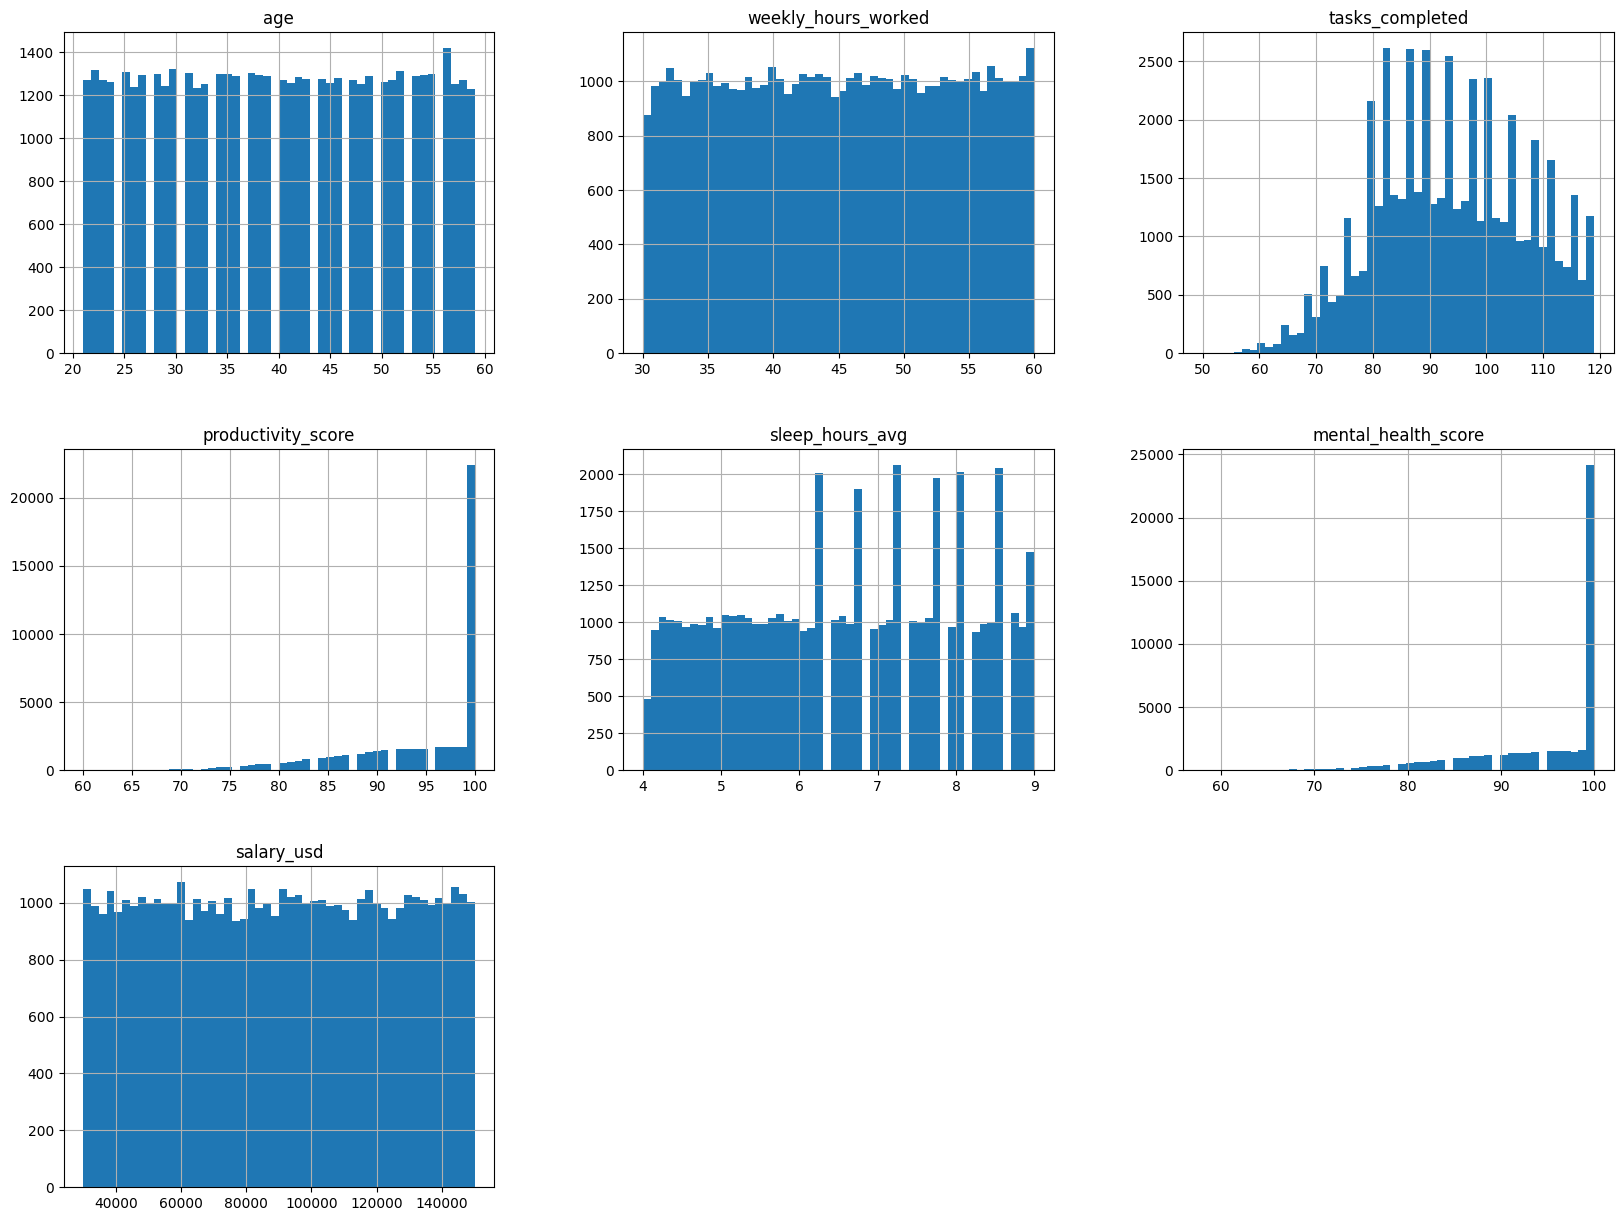

In [3]:
num_attributes = ['age', 'weekly_hours_worked', 'tasks_completed', 'productivity_score', 'sleep_hours_avg', 'mental_health_score', 'salary_usd']
df[num_attributes].hist(bins=50, figsize=(20,15))
plt.show()

## Class distribution of the target variable – `burnout_level`

The distribution of the target variable is:

- Low (0): 23,270 instances  
- High (2): 13,461 instances  
- Medium (1): 13,269 instances  

## Class distribution of the target variable – `burnout_level` (normalized)

The proportional distribution of the target variable is:

- Low (0): 46.54%  
- High (2): 26.92%  
- Medium (1): 26.54%  

This indicates that the dataset is moderately imbalanced, with the Low burnout class being the most frequent. The Medium and High classes have a similar number of instances.

Because of this imbalance, it is more appropriate to evaluate models using metrics such as **macro F1-score** and **balanced accuracy**, rather than accuracy alone.

In [4]:
class_counts = df["burnout_level"].value_counts().sort_index()

print("Class distribution (counts):")
print("Low (0):", class_counts[0])
print("Medium (1):", class_counts[1])
print("High (2):", class_counts[2])

Class distribution (counts):
Low (0): 23270
Medium (1): 13269
High (2): 13461


In [5]:
df['burnout_level'].value_counts(normalize=True)

,proportion
burnout_level,
0,0.46540
2,0.26922
1,0.26538


##Feature engineering
Feature engineering was applied to improve model performance by creating new variables that better capture employee well-being and workload balance.

- stress_index combines workload (tasks) and recovery (sleep)
- wellbeing combines mental health and job satisfaction
- categorical versions of continuous variables were created to capture non-linear patterns

In [6]:
df["sleep_cat"] = pd.cut(df["sleep_hours_avg"], bins=3, labels=[0,1,2])
df["mental_cat"] = pd.cut(df["mental_health_score"], bins=3, labels=[0,1,2])

df["stress_index"] = df["tasks_completed"] / df["sleep_hours_avg"]
df["wellbeing"] = df["mental_health_score"] + df["job_satisfaction"]

df = df.drop(columns=["year", "work_mode"])

##Split Data

A stratified train-test split was used to preserve the original class distribution of burnout levels, ensuring that the model is trained and evaluated on representative samples of all classes.

In [7]:
X = df.drop(columns=["burnout_level", "weekly_hours_worked"])
y = df["burnout_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Correlation Analysis

To better understand relationships between numerical variables, a correlation matrix was computed and visualized using a heatmap.

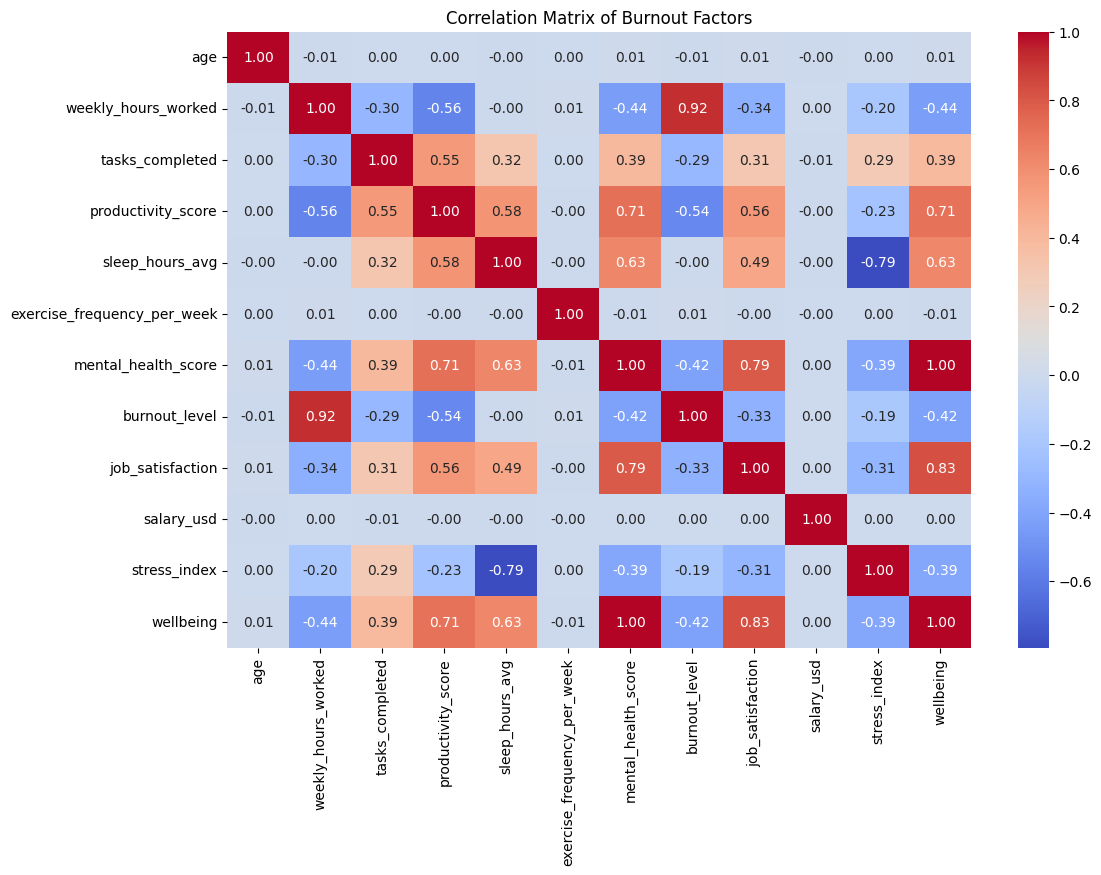

In [8]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Burnout Factors")
plt.show()

## Data Preprocessing

Numerical features are scaled using `StandardScaler` to ensure comparable value ranges across variables, which is particularly important for distance-based models such as SVM.

Categorical features are encoded using `OneHotEncoder`, transforming each category into binary variables without introducing ordinal relationships. The parameter `handle_unknown="ignore"` ensures robustness when unseen categories appear in the test set.

A `ColumnTransformer` is used to apply these transformations consistently within a unified pipeline. Although tree-based models do not strictly require feature scaling, it is applied for consistency across all models.

In [9]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

dt_pruned = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=0.0005
    ))
])

dt_pruned.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'tasks_completed', 'productivity_score', 'sleep_hours_avg',
       'exercise_frequency_per_week', 'mental_health_score',
       'job_satisfaction', 'salary_usd', 'stress_index', 'wellbeing'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['country', 'industry', 'sleep_cat', 'mental_cat'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(ccp_alpha=0.0005, random_state=42))])

##Chosen Models

Multiple models were tested to compare performance:

- Decision Tree: simple baseline model
- SVM: effective for high-dimensional data
- Random Forest: robust ensemble method handling non-linear relationships
- AdaBoost: boosting-based ensemble method

In [10]:
dt_model = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [11]:
svm_model = Pipeline([
    ("prep", preprocess),
    ("model", SVC(kernel="linear"))
])

In [12]:
rf_model = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [13]:
ada_model = Pipeline([
    ("prep", preprocess),
    ("model", AdaBoostClassifier(random_state=42))
])

## Grid Search

I used `GridSearchCV` to optimize the Random Forest model by testing different combinations of hyperparameters such as `n_estimators`, `max_depth`, and `min_samples_split`.

StratifiedKFold with 3 splits was used to preserve class distribution during cross-validation, and the model was evaluated using F1 macro.

This process helps select the best model configuration and improves generalization performance.

In [14]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}
grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
Best CV score: 0.6483836745821822


## Feature Selection

Feature selection using `SelectKBest` was applied to identify the most relevant predictors and build a simplified model using only the top-ranked features.

The objective is to evaluate whether reducing the feature space improves generalization, reduces overfitting, and increases model interpretability.

The slim model is implemented as a pipeline and evaluated on the test set using F1-macro and balanced accuracy.


In [15]:
slim_model = Pipeline([
    ("prep", preprocess),
    ("select", SelectKBest(f_classif, k=5)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

slim_model.fit(X_train, y_train)
preds = slim_model.predict(X_test)

print("SLIM MODEL")
print(f1_score(y_test, preds, average="macro"))
print(balanced_accuracy_score(y_test, preds))

SLIM MODEL
0.4776832295486206
0.4845792090498166


## Model Training and Evaluation

All models were trained using a stratified train-test split to preserve class distribution. Performance was evaluated on the test set using F1-macro and balanced accuracy, suitable for imbalanced classification.

Models were compared under identical conditions to ensure a fair evaluation. The results show that ensemble methods, especially Random Forest, achieve the best performance, while the Slim model performs worst due to loss of important features through feature selection.

In [16]:
models = {
    "Decision Tree": dt_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
    "Slim RF": slim_model,
    "Best RF": best_rf
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("\n====", name, "====")
    print("F1 macro:", f1_score(y_test, preds, average="macro"))
    print("Balanced accuracy:", balanced_accuracy_score(y_test, preds))


==== Decision Tree ====
F1 macro: 0.56035916474231
Balanced accuracy: 0.5605450132849185

==== SVM ====
F1 macro: 0.6193146679710675
Balanced accuracy: 0.6222628767417304

==== Random Forest ====
F1 macro: 0.6410172397111157
Balanced accuracy: 0.6465667729914807

==== AdaBoost ====
F1 macro: 0.6246445106580621
Balanced accuracy: 0.6269123734194545

==== Slim RF ====
F1 macro: 0.4776832295486206
Balanced accuracy: 0.4845792090498166

==== Best RF ====
F1 macro: 0.6462109790709089
Balanced accuracy: 0.652227435886075


##Training vs Testing Performance

To evaluate potential overfitting, the performance of the best Random Forest model was measured on both the training and test sets using the F1-macro score.

The training score represents how well the model fits the data it has already seen, while the test score reflects its ability to generalize to unseen data.

In [17]:
train_pred = best_rf.predict(X_train)
test_pred = best_rf.predict(X_test)

print("Train F1:", f1_score(y_train, train_pred, average="macro"))
print("Test F1:", f1_score(y_test, test_pred, average="macro"))

Train F1: 0.9075254826424858
Test F1: 0.6462109790709089


##Feature Importance Analysis
To interpret the decision-making process of the best-performing Random Forest model, feature importance values were extracted and visualized. This analysis ranks the input variables based on their contribution to the model’s predictions.

The top 10 most important features are displayed in descending order of importance, highlighting which factors have the strongest influence on predicting employee burnout.

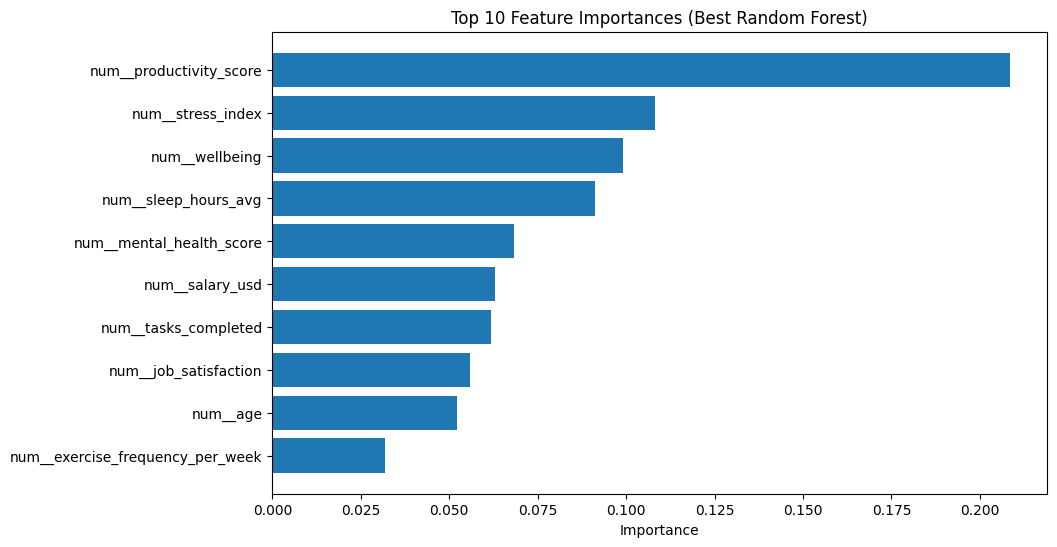

In [18]:
feat_names = best_rf.named_steps["prep"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top = importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("Top 10 Feature Importances (Best Random Forest)")
plt.xlabel("Importance")
plt.show()

##Confusion Matrix
To better understand the performance of each model beyond overall metrics, confusion matrices were generated for all classifiers. These matrices provide a detailed view of correct and incorrect predictions for each burnout class (Low, Medium, High).

The comparison includes both baseline models (Decision Tree, SVM, Random Forest, AdaBoost) and improved versions (Pruned Decision Tree, Slim RF, and Optimized Random Forest).



In [19]:
def plot_cm(model, X_test, y_test, title):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()

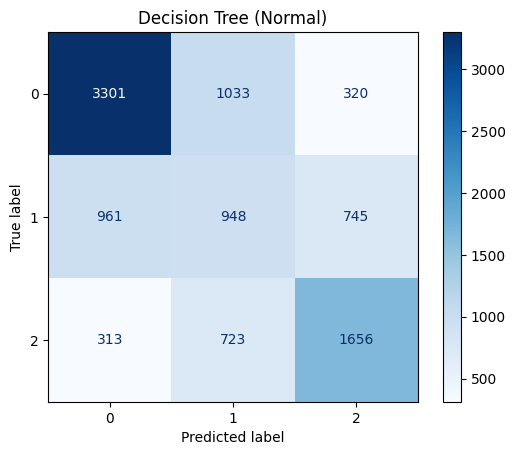

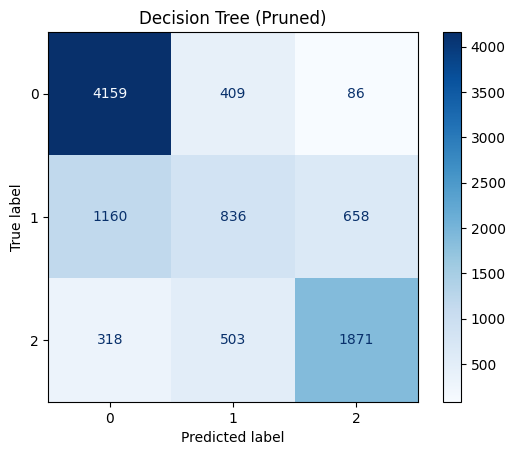

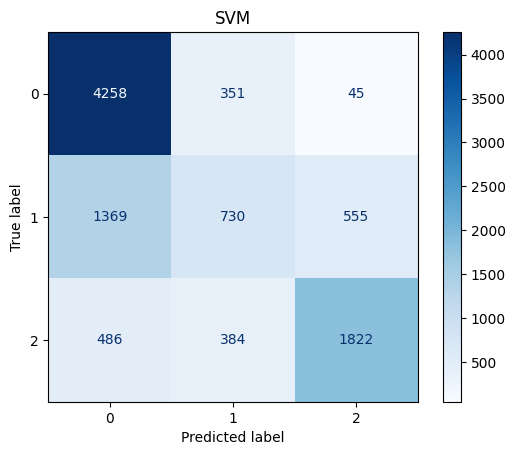

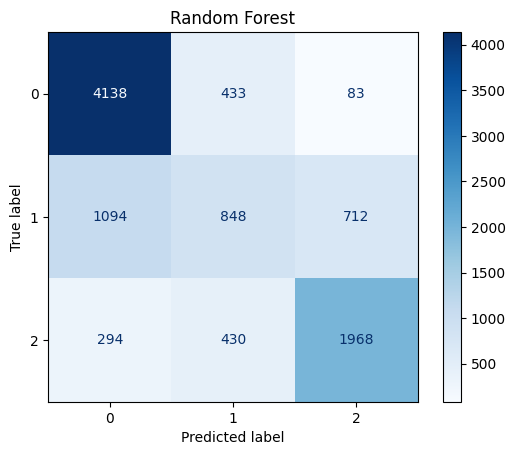

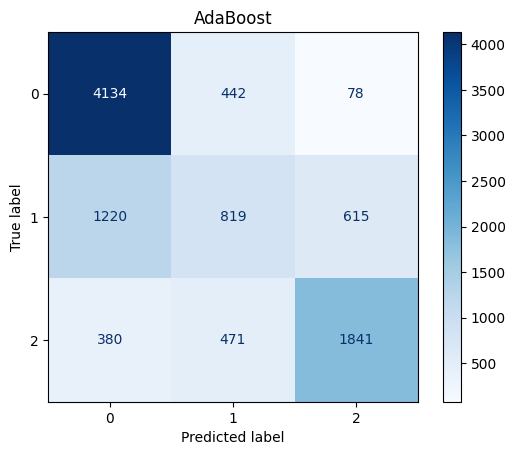

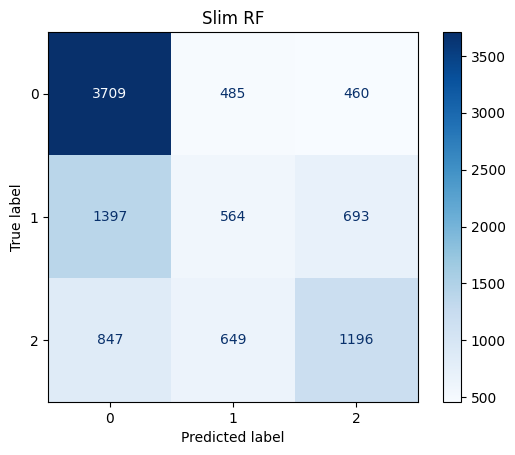

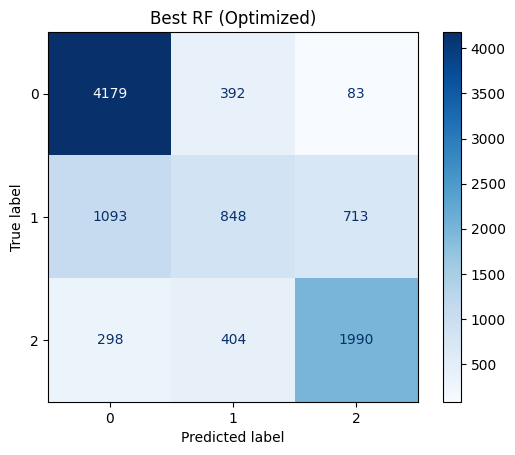

In [20]:
models = {
    "Decision Tree (Normal)": dt_model,
    "Decision Tree (Pruned)": dt_pruned,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
    "Slim RF": slim_model,
    "Best RF (Optimized)": best_rf
}

for name, model in models.items():
    plot_cm(model, X_test, y_test, name)

##Decision Tree Comparison
The pruned Decision Tree significantly outperforms the standard Decision Tree, increasing F1-macro from approximately 0.56 to 0.63.

This indicates that the unpruned model was overfitting the training data by creating overly complex decision paths. Pruning reduces model complexity by removing weak branches, leading to improved generalization and better performance on unseen data.

In [21]:
print("NORMAL DT")
print(f1_score(y_test, dt_model.predict(X_test), average="macro"))

print("PRUNED DT")
print(f1_score(y_test, dt_pruned.predict(X_test), average="macro"))

NORMAL DT
0.56035916474231
PRUNED DT
0.6310709643908613


##Full vs Slim Model Comparison

The full Random Forest model achieves significantly better performance (F1 macro ≈ 0.65) compared to the slim model (F1 macro ≈ 0.48).

This indicates that feature selection reduced model complexity but also removed important predictive information, leading to lower performance.

Therefore, while the slim model is more interpretable, the full model provides better predictive accuracy.

In [22]:
full_preds = best_rf.predict(X_test)
slim_preds = slim_model.predict(X_test)

print("FULL RF F1:", f1_score(y_test, full_preds, average="macro"))
print("SLIM RF F1:", f1_score(y_test, slim_preds, average="macro"))

FULL RF F1: 0.6462109790709089
SLIM RF F1: 0.4776832295486206


##FEATURE ENGINEERING IMPACT

Feature engineering had a model-dependent impact. Linear models such as SVM benefited significantly, while ensemble methods like Random Forest showed minimal improvement. Tree-based models and boosting methods exhibited slight performance degradation, likely due to redundancy and noise introduced by engineered features.

In [23]:
df_no_feat = df.drop(columns=[
    "sleep_cat",
    "mental_cat",
    "stress_index",
    "wellbeing"
], errors="ignore")

X_nf = df_no_feat.drop(columns=["burnout_level", "weekly_hours_worked"])
y_nf = df_no_feat["burnout_level"]

X_train_nf, X_test_nf, y_train_nf, y_test_nf = train_test_split(
    X_nf, y_nf,
    test_size=0.2,
    random_state=42,
    stratify=y_nf
)

num_features_nf = X_nf.select_dtypes(include=["int64", "float64"]).columns
cat_features_nf = X_nf.select_dtypes(include=["object", "category"]).columns

preprocess_nf = ColumnTransformer([
    ("num", StandardScaler(), num_features_nf),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_nf)
])

dt_nf = Pipeline([
    ("prep", preprocess_nf),
    ("model", DecisionTreeClassifier(random_state=42))
])

svm_nf = Pipeline([
    ("prep", preprocess_nf),
    ("model", SVC(kernel="linear"))
])

rf_nf = Pipeline([
    ("prep", preprocess_nf),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

ada_nf = Pipeline([
    ("prep", preprocess_nf),
    ("model", AdaBoostClassifier(random_state=42))
])

slim_nf = Pipeline([
    ("prep", preprocess_nf),
    ("select", SelectKBest(f_classif, k=5)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

best_rf_nf = Pipeline([
    ("prep", preprocess_nf),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

models_without = {
    "Decision Tree": dt_nf,
    "SVM": svm_nf,
    "Random Forest": rf_nf,
    "AdaBoost": ada_nf,
    "Slim RF": slim_nf,
    "Best RF": best_rf_nf
}


rf_nf.fit(X_train_nf, y_train_nf)
pred_nf = rf_nf.predict(X_test_nf)

In [24]:
results = []
models_with = {
    "Decision Tree": dt_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
    "Slim RF": slim_model,
    "Best RF": best_rf
}

for name in models_with.keys():

    model_w = models_with[name]
    model_w.fit(X_train, y_train)
    preds_w = model_w.predict(X_test)

    f1_w = f1_score(y_test, preds_w, average="macro")
    bal_w = balanced_accuracy_score(y_test, preds_w)

    model_nf = models_without[name]
    model_nf.fit(X_train_nf, y_train_nf)
    preds_nf = model_nf.predict(X_test_nf)

    f1_nf = f1_score(y_test_nf, preds_nf, average="macro")
    bal_nf = balanced_accuracy_score(y_test_nf, preds_nf)

    results.append([
        name,
        f1_w, f1_nf, f1_w - f1_nf,
        bal_w, bal_nf, bal_w - bal_nf
    ])

df_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "F1 WITH", "F1 WITHOUT", "Δ F1",
        "BAL WITH", "BAL WITHOUT", "Δ BAL"
    ]
)

print(df_results.sort_values(by="Δ F1", ascending=False))

           Model   F1 WITH  F1 WITHOUT      Δ F1  BAL WITH  BAL WITHOUT  \
1            SVM  0.619315    0.601838  0.017477  0.622263     0.607463   
5        Best RF  0.646211    0.639669  0.006542  0.652227     0.647237   
2  Random Forest  0.641017    0.639669  0.001348  0.646567     0.647237   
0  Decision Tree  0.560359    0.564435 -0.004076  0.560545     0.564014   
3       AdaBoost  0.624645    0.638243 -0.013599  0.626912     0.635777   
4        Slim RF  0.477683    0.491367 -0.013684  0.484579     0.497612   

      Δ BAL  
1  0.014800  
5  0.004991  
2 -0.000670  
0 -0.003469  
3 -0.008865  
4 -0.013033  


## Final Conclusion

Random Forest achieved the best overall performance and was selected as the final model, obtaining the highest F1-macro and balanced accuracy among all evaluated models.

However, the model shows mild signs of overfitting, as the training performance is higher than the test performance, although the gap remains acceptable.

SVM also performed well, benefiting from feature scaling and showing competitive results. Decision Tree achieved lower performance due to its simplicity and tendency to overfit when not pruned.

AdaBoost provided competitive but slightly lower results compared to ensemble-based methods such as Random Forest.

The Slim model achieved significantly lower performance compared to the full model, indicating that aggressive feature selection removed important predictive information.

The medium burnout class remains the most difficult to predict across all models due to overlapping feature distributions, suggesting inherent class ambiguity in the dataset.

In [25]:
results = []

for name, model in models.items():
    preds = model.predict(X_test)
    results.append([
        name,
        f1_score(y_test, preds, average="macro"),
        balanced_accuracy_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=["Model", "F1 Macro", "Balanced Accuracy"])
results_df.sort_values(by="F1 Macro", ascending=False)

,Model,F1 Macro,Balanced Accuracy
6,Best RF (Optimized),0.646211,0.652227
3,Random Forest,0.641017,0.646567
1,Decision Tree (Pruned),0.631071,0.634553
4,AdaBoost,0.624645,0.626912
2,SVM,0.619315,0.622263
0,Decision Tree (Normal),0.560359,0.560545
5,Slim RF,0.477683,0.484579
